In [66]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftshift, fftfreq
import time

# Question 1

B.) Numerically compute the Discrete Fourier Transform of (1) on [0, 1] for three different
values of N. Use the conventions

$f(x) = e^{-50(x-\frac{1}{2})^2}$ (1)

$X_m = \sum_{n=0}^{N-1} x_n e^{-i 2 \pi \frac{m n}{N}}$ (3)

$x_n = \frac{1}{N} \sum_{m=0}^{N-1} X_m e^{i 2 \pi \frac{m n}{N}}$      (4)

for the discrete Fourier transform and the inverse discrete Fourier transform. Plot
the three transforms on one plot alongside your analytical result. Invert your k-space
results and compare them to (1).

In [67]:
# Define Equation 1
def func(x_arr):
    return np.exp(-50 * (x_arr - 0.5)**2)

In [68]:
# Define analytical solution from A. Note: Absolute value drops imaginary term
def analytical_func(k_arr):
    return np.sqrt(np.pi / 50) * np.exp(-k_arr**2 / 200)

In [69]:
# Define discrete_fourier function (Equation 3). Calculates the decrete Fourier transform using Equation (1) and Equation (3).
# Takes the desired number of steps N and outputs the transformed k-space array (m_arr), x_array and calculated Xm_array
def discrete_fourier(n_val):
    x_arr = np.linspace(0, 1, n_val)
    m_arr = np.arange(0, n_val, 1)
    n_arr = m_arr
    Xm_arr = np.array([])
    for m in m_arr:
        Xm = np.sum(np.exp((-50 * (x_arr - 0.5)**2) - ((1J * 2 * np.pi * m * n_arr) / n_val)))
        Xm_arr = np.append(Xm_arr, Xm)

    return m_arr, x_arr, Xm_arr

In [70]:
# Define inverse_discrete_fourier function (Equation 4). Calculates the inverse decrete Fourier transform using Equation (3) and Equation (4).
# Takes a previously calculated Xm and the desired number of steps N and outputs the calculated xn_array.
# n_val should be the same n_val passed through discrete_fourier
def inverse_discrete_fourier(Xm_arr, n_val):
    m_arr = np.arange(0, n_val, 1)
    n_arr = m_arr
    xn_arr = np.array([])
    for n in n_arr:
        xn = np.sum(Xm_arr * np.exp(((1J * 2 * np.pi * n * m_arr) / n_val))) / n_val
        xn_arr = np.append(xn_arr, xn)

    return xn_arr

In [71]:
# Calculate discrete Fourier Transform for N = 100, 300, and 500
k_100, x_100, Xm_100 = discrete_fourier(100)
k_300, x_300, Xm_300 = discrete_fourier(300)
k_500, x_500, Xm_500 = discrete_fourier(500)

(0.0, 100.0)

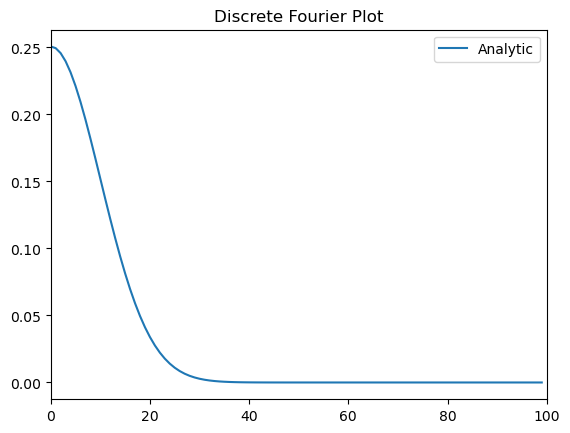

In [72]:
# Plot analytic answer by itself first with N = 100
plt.plot(k_100, analytical_func(k_100), label = "Analytic")
plt.title("Discrete Fourier Plot")
plt.legend()
plt.xlim(0, 100)

(0.0, 10.0)

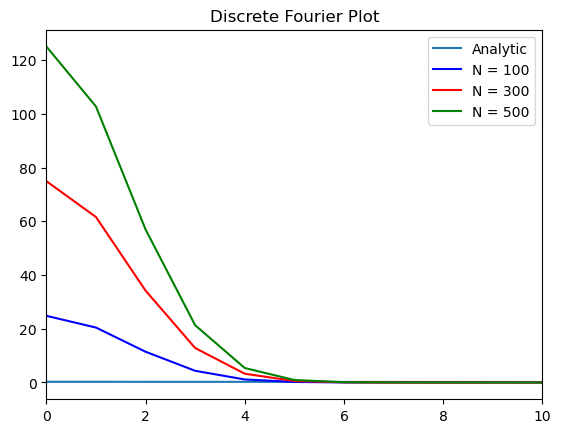

In [73]:
# Plot each Fourier Transform together. Plotting the absolute value of Xm for each.
plt.plot(k_100, analytical_func(k_100), label = "Analytic")
plt.plot(k_100, abs(Xm_100), "b-", label = "N = 100")
plt.plot(k_300, abs(Xm_300), "r-", label = "N = 300")
plt.plot(k_500, abs(Xm_500), "g-", label = "N = 500")
plt.title("Discrete Fourier Plot")
plt.legend()
plt.xlim(0, 10)

Note: Each answer is not normalized, so analytic solution will look almost flat compared to the others

In [74]:
# Calculate the inverse discrete Fourier transform
inv_x_100 = inverse_discrete_fourier(Xm_100, 100)
print(inv_x_100)

[3.72665317e-06+7.73436870e-15j 6.14389891e-06+1.69975145e-15j
 1.00262383e-05+4.52526905e-15j 1.61957424e-05+3.21520588e-15j
 2.58959932e-05+6.44373443e-15j 4.09857759e-05+4.84501328e-15j
 6.42099934e-05+1.00364161e-15j 9.95728564e-05+1.24611432e-14j
 1.52843925e-04+4.25881552e-15j 2.32233182e-04+4.77839990e-15j
 3.49276399e-04+1.60760294e-15j 5.19975743e-04+5.68434189e-15j
 7.66241736e-04+1.32338585e-15j 1.11767979e-03+3.83693077e-15j
 1.61375600e-03-7.28306304e-16j 2.30636063e-03+3.76587650e-15j
 3.26276232e-03-7.81597009e-16j 4.56890930e-03-2.85993451e-15j
 6.33298575e-03+1.91846539e-15j 8.68907130e-03+3.23296945e-15j
 1.18006814e-02-1.42108547e-15j 1.58638899e-02-2.73558953e-15j
 2.11096565e-02+1.29674049e-15j 2.78049116e-02+4.79616347e-15j
 3.62518979e-02-6.67910172e-15j 4.67852390e-02-7.42517159e-15j
 5.97662260e-02-1.35003120e-15j 7.55738747e-02-1.27897692e-15j
 9.45924385e-02-7.56728014e-15j 1.17195255e-01-3.16191517e-15j
 1.43725065e-01-1.42108547e-15j 1.74471250e-01-1.065814

Text(0.5, 1.0, 'Inverse Discrete Fourier Plot')

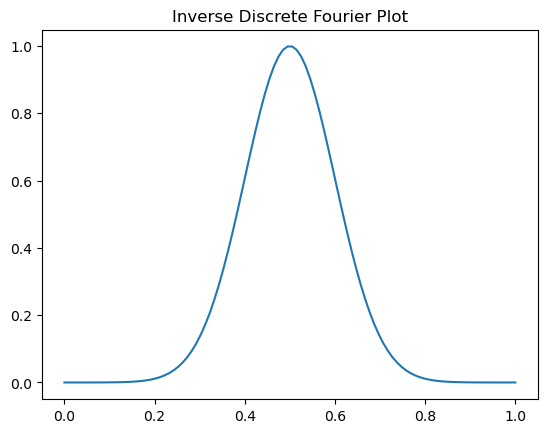

In [75]:
# Plot inverse discrete Fourier transform
plt.plot(x_100, abs(inv_x_100))
plt.title("Inverse Discrete Fourier Plot")

Text(0.5, 1.0, 'Standard Equation 1 Plot')

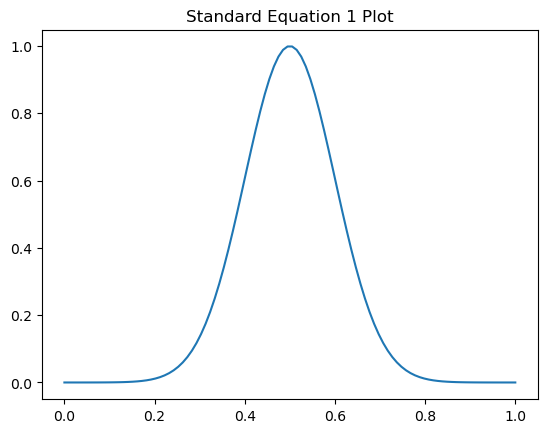

In [76]:
# Plot Equation 1
func_x = np.linspace(0, 1, 100)
func_y = func(func_x)

plt.plot(func_x, func_y)
plt.title("Standard Equation 1 Plot")

C.) Use an off-the-shelf FFT algorithm (for example scipy.fft from python) and do the
Fourier transform of the function in eq. (1). Compare the FFT and DFT on the same
plot. Time the code for your DFT simulation and the FFT simulation with increasing
number of grid points. Make a time complexity plot (execution time vs. N) and
compare it with the DFT algorithm that you implemented in (B). Use N = $2^j$
, j = 3, ..., 11 for the DFT and N = $2^j$ , j = 3, ..., 20 for the FFT. Since the FFT calculation
is very fast, it is susceptible to noise for small N. Average each time over 100 runs for
both the DFT and FFT. Plot the times on a log–log plot as a function of N. Comment
on your observations.

(0.0, 0.1)

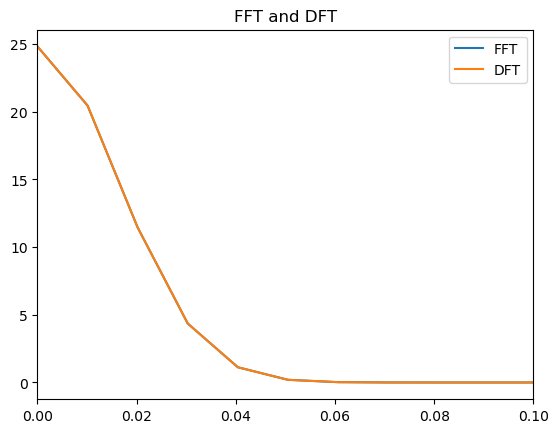

In [77]:
# Use scipy.fft and plot alongside DFT
fft_x = np.linspace(0, 1, 100) # Using same number of points as N = 100 DFT
fft_y = fft(func(fft_x))

plt.plot(fft_x, abs(fft_y), label = "FFT")
plt.plot(x_100, abs(Xm_100), label = "DFT")
plt.legend()
plt.title("FFT and DFT")
plt.xlim(0, 0.1)

Both functions are exactly the same on this plot

/home/j_call/miniconda3/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/j_call/miniconda3/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0.5, 1.0, 'Inverse FFT')

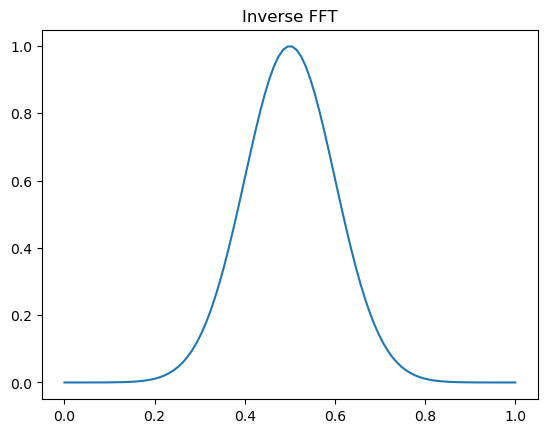

In [78]:
# Calculate and plot the inverse FFT
inverse_fft_y = ifft(fft_y)

plt.plot(fft_x, inverse_fft_y) # Should be exact same as plotted Equation 1
plt.title("Inverse FFT")

In [82]:
# Use time package to time DFT and FFT over different runs
dft_run_time = np.array([])
dft_time = np.array([])
for j in range(3, 12):
    dft_N = 2**j
    for x in range(0, 100):
        start = time.perf_counter()
        stock_k, stock_x, stock_xm = discrete_fourier(dft_N)
        end = time.perf_counter()
        dft_run_time = np.append(dft_run_time, end - start)
    avg_time = np.average(dft_run_time)
    dft_time = np.append(dft_time, avg_time)
    
fft_run_time = np.array([])
fft_time = np.array([])
for j in range(3, 21):
    fft_N = 2**j
    fft_x = np.linspace(0, 1, fft_N)
    for x in range(0, 100):
        start = time.perf_counter()
        stock_y = fft(func(fft_x))
        end = time.perf_counter()
        fft_run_time = np.append(fft_run_time, end - start)
    avg_time = np.average(fft_run_time)
    fft_time = np.append(fft_time, avg_time)

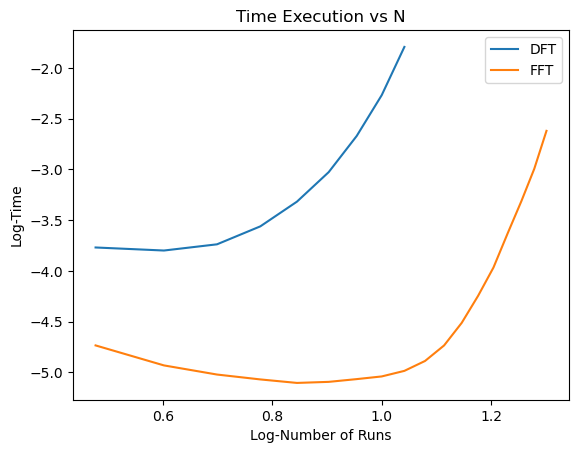

In [83]:
# Plot execution time versus N
dft_N_arr = np.arange(3, 12, 1)
fft_N_arr = np.arange(3, 21, 1)

plt.plot(np.log10(dft_N_arr), np.log10(dft_time), label = "DFT")
plt.plot(np.log10(fft_N_arr), np.log10(fft_time), label = "FFT")
plt.xlabel("Log-Number of Runs")
plt.ylabel("Log-Time")
plt.title("Time Execution vs N")
plt.legend()

Clearly, for all values of N, DFT runs much longer than FFT. They appear to have the same increase in time with number of runs, but with the increase shooting up at a different N value.

# Question 2

We can use the Fourier transform to solve the 1D heat equation

$\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}$ (5)

$u(x, 0) = e^{-50(x-\frac{1}{2})^2}$ (6)

By using a property of the Fourier transform,

$F (\frac{d^n f}{d x^n}) = (ik)^n f(k)$ (7)

The heat equation transforms into

$\frac{\partial u}{\partial t} = -\alpha k^2 u$ (8)

$u(k, 0) = F[e^{-50(x - \frac{1}{2})^2}]$

A.) Use the DFT code that you set up in problem 1 to Fourier transform the initial heat
distribution (6). Use an Euler/Runge–Kutta numerical integrator to solve (8) in kspace. Use the inverse Fourier transform (4) to go back to position space. Choose
x ∈ [0, 1], α = 0.005, time step ∆t = 0.001 and total integration time T = 5. Plot the
solution as a function of space(x-axis) and time(y-axis) with a color plot. Calculate
the total heat at each time step, what do you notice?

In [88]:
# Define Equation 8
def heat(alpha, k_arr, u_hat_val):
    return -alpha * (k_arr**2) * u_hat_val

In [89]:
# Use previously written RK2 integration function
# RK2 Runge-Kutta Numerical Integration. Uses the Modified Euler Method value of b = 1/2. Takes a differential equation, 
# some initial and final x, an initial y, along with an integer to divide xf - xi by to determine the step size h. 
# Iteratively calculates the integral of a given function (here, a hard-coded function above). 
# Returns an array for the x values, y values, and the final y value.
def runge_kutta_2(fxn, initial_x, final_x, initial_y, steps):
    # Initialize variables
    x_arr = np.array([])
    y_arr = np.array([])
    x_arr = np.append(x_arr, initial_x) # Place first element of x
    y_arr = np.append(y_arr, initial_y) # Place first element of y

    # First calculations
    h = (final_x - initial_x) / steps # Step size
    x_new = initial_x + h
    x_arr = np.append(x_arr, x_new)
    K1 = fxn(initial_y)
    K2 = fxn(initial_y + (h * K1))
    y_new = initial_y + ((h * (K1 + K2)) / 2)
    y_arr = np.append(y_arr, y_new)

    # Iterate by steps of x until final_x is reached. Print the variables in each step
    while x_new < final_x:
        x_new = x_new + h
        x_arr = np.append(x_arr, x_new)
        K1 = fxn(y_new)
        K2 = fxn(y_new + (h * K1))
        y_new = y_new + ((h * (K1 + K2)) / 2)
        y_arr = np.append(y_arr, y_new)

    return x_arr, y_arr, y_new

In [ ]:
# Parameters
N = 100 # Following as before
alpha = 0.005
dt = 0.001
T = 5
time_steps = np.arange(0, T, dt)
m_arr = fftfreq(N, d = 1 / N)
k_arr = 2 * np.pi * m_arr # k-space array

# Initial k-space condition
x_arr = np.arange(N) / N
u_initial = np.exp(-50 * (x_arr - 0.5)**2)
u_hat = fft(u_initial)

# Arrays to store our results for plotting
plot_interval = 50 
u_space_time = np.zeros((time_steps // plot_interval, N))
total_heat = np.zeros(time_steps)

# 3. Time Integration Loop (RK2 Method in k-space)
for t in range(time_steps):
    
    # Calculate total heat (The k=0 component scaled by 1/N)
    total_heat[t] = np.real(u_hat[0]) / N
    
    # Store real-space distribution for the color plot occasionally
    if t % plot_interval == 0:
        u_x = ifft(u_hat)
        u_space_time[t // plot_interval, :] = np.real(u_x)
        
    # --- YOUR RK2 LOGIC ---
    K1 = heat(alpha, k_arr, u_hat)
    K2 = heat(alpha, k_arr, u_hat + (dt * K1))
    u_hat = u_hat + ((dt * (K1 + K2)) / 2)

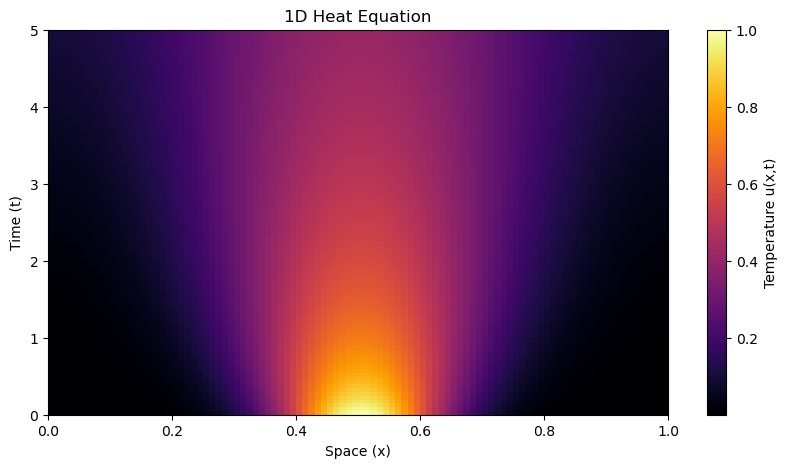

In [91]:
# Color plot of space vs time
plt.figure(figsize=(10, 5))
plt.imshow(u_space_time, aspect = 'auto', origin = 'lower', extent = [0, 1, 0, T], cmap = 'inferno')
plt.colorbar(label = 'Temperature u(x,t)')
plt.xlabel('Space (x)')
plt.ylabel('Time (t)')
plt.title("1D Heat Equation")
plt.show()

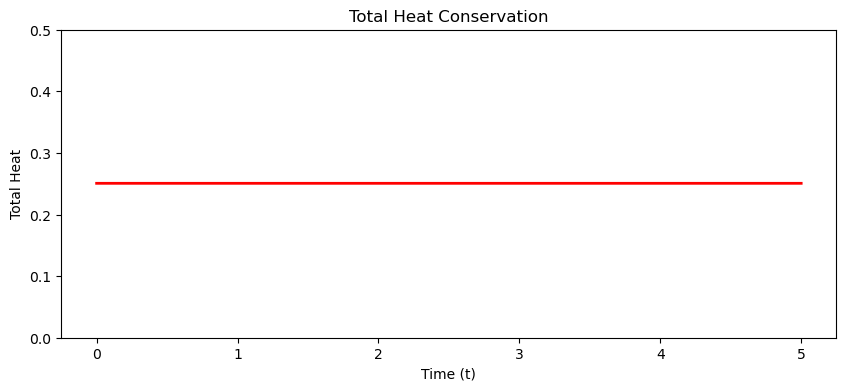

In [92]:
# Plot of total heat over time
plt.figure(figsize=(10, 4))
plt.plot(np.linspace(0, T, time_steps), total_heat, 'r-', lw=2)
plt.ylim(0, 0.5)
plt.xlabel('Time (t)')
plt.ylabel('Total Heat')
plt.title('Total Heat Conservation')
plt.show()

B.) Now choose any other α (say 0.05) and time step (say ∆t = 0.01). What do you
observe? Can you comment on the stability of the time-step and α? Comment on your
findings.
